# From Scratch to Production: An Educational Tutorial on Neural Networks

Welcome to this comprehensive, step-by-step tutorial on Artificial Neural Networks (ANNs).

This notebook is designed to take you from a foundational understanding of the mathematics behind deep learning to writing your own fully modular neural network from scratch in NumPy, and finally building a state-of-the-art, production-quality deep learning pipeline using PyTorch.

---

## 1. Mathematical Formulation & Problem Setup

### The Core Task
Our objective is to train artificial neural networks to solve a fundamental regression problem in statistical inference.

Specifically, we are given a sequence of $D = 12$ independent samples drawn from a 1D Gaussian distribution:
$$x_1, x_2, \dots, x_D \sim \mathcal{N}(\mu, \sigma^2)$$

Our goal is to build an ANN that takes the 12-dimensional vector $X = [x_1, x_2, \dots, x_D]^T$ as input and predicts the underlying parameters that generated the sequence:
1. **The True Mean ($\mu$)**, which is generated uniformly in the range $[-5.0, 5.0]$.
2. **The True Variance ($\sigma^2$)**, which is generated uniformly in the range $[0.5, 9.0]$ (standard deviations $\sigma \in [\sqrt{0.5}, 3.0]$).

Thus, the input to our neural network is a vector $X \in \mathbb{R}^{12}$, and the target is a vector $Y = [\mu, \sigma^2]^T \in \mathbb{R}^2$.

---

### Why is this task interesting?
From classical statistics, we know that the optimal estimators for the mean and variance of a Gaussian sample are:
* **The Sample Mean** (the MVUE - Minimum Variance Unbiased Estimator):
$$\bar{x} = \frac{1}{D} \sum_{i=1}^{D} x_i$$
* **The Sample Variance** (the unbiased sample variance):
$$s^2 = \frac{1}{D-1} \sum_{i=1}^{D} (x_i - \bar{x})^2 = \frac{1}{D-1} \sum_{i=1}^{D} x_i^2 - \frac{D}{D-1} \bar{x}^2$$

The sample mean is a *linear* function of the inputs, whereas the sample variance is a *quadratic* non-linear function of the inputs.
By attempting to predict $\mu$ and $\sigma^2$ from $X$, we are asking our neural networks to learn both a simple linear relationship and a complex non-linear relationship directly from raw sequences!

---

## 2. Environment Setup

First, let's import the necessary libraries and set random seeds to guarantee exact reproducibility of our experiments.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
import os
import time
import imageio
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Environment setup complete. PyTorch Version:", torch.__version__)


Environment setup complete. PyTorch Version: 2.13.0+cu130


## 3. Dataset Generation & Normalization

To ensure our models train efficiently, we must generate a high-quality dataset. Here is how we do it:
1. Generate the latent parameters: $\mu \sim \mathcal{U}(-5.0, 5.0)$ and $\sigma^2 \sim \mathcal{U}(0.5, 9.0)$ for each sample.
2. Generate $D=12$ Gaussian samples for each sample using its latent $\mu$ and $\sigma$.
3. Split the data into **Training** (70%), **Validation** (15%), and **Test** (15%) splits.
4. Scale/standardize the dataset. Regression targets and inputs can have wide scales, and normalizing them to have zero mean and unit variance ($\mu=0, \sigma=1$) helps gradient-based optimization converge significantly faster.

Let's write a robust dataset generator and a scaling utility class.


In [2]:
class Standardizer:
    """Utility class to scale inputs and targets to zero mean and unit variance."""
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, data):
        self.mean = np.mean(data, axis=0, keepdims=True)
        self.std = np.std(data, axis=0, keepdims=True)
        # Avoid division by zero
        self.std[self.std == 0.0] = 1.0

    def transform(self, data):
        return (data - self.mean) / self.std

    def fit_transform(self, data):
        self.fit(data)
        return self.transform(data)

    def inverse_transform(self, data):
        return data * self.std + self.mean

def generate_gaussian_dataset(num_samples=10000, sequence_length=12):
    """Generates a dataset of 12D vectors sampled from Gaussian distributions with uniform mean and variance."""
    # 1. Generate uniform parameters
    # Mean: [-5.0, 5.0]
    true_means = np.random.uniform(-5.0, 5.0, size=(num_samples, 1))
    # Variance: [0.5, 9.0]
    true_vars = np.random.uniform(0.5, 9.0, size=(num_samples, 1))
    true_stds = np.sqrt(true_vars)

    # 2. Sample 12D sequences
    # X_i = mean_i + std_i * Z, where Z ~ N(0, I)
    Z = np.random.normal(0.0, 1.0, size=(num_samples, sequence_length))
    X = true_means + true_stds * Z

    # 3. Targets: Concatenate true_mean and true_var
    Y = np.hstack([true_means, true_vars])

    return X, Y

# Generate the raw data
X_raw, Y_raw = generate_gaussian_dataset(num_samples=12000, sequence_length=12)

# Split into Train (70%), Val (15%), Test (15%)
n_total = len(X_raw)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

X_train_raw, Y_train_raw = X_raw[:n_train], Y_raw[:n_train]
X_val_raw, Y_val_raw = X_raw[n_train:n_train+n_val], Y_raw[n_train:n_train+n_val]
X_test_raw, Y_test_raw = X_raw[n_train+n_val:], Y_raw[n_train+n_val:]

# Fit standardizers on the training split only (to avoid data leakage!)
input_scaler = Standardizer()
target_scaler = Standardizer()

X_train = input_scaler.fit_transform(X_train_raw)
Y_train = target_scaler.fit_transform(Y_train_raw)

X_val = input_scaler.transform(X_val_raw)
Y_val = target_scaler.transform(Y_val_raw)

X_test = input_scaler.transform(X_test_raw)
Y_test = target_scaler.transform(Y_test_raw)

print(f"Dataset generated and scaled:")
print(f"Train Split: X = {X_train.shape}, Y = {Y_train.shape}")
print(f"Val Split:   X = {X_val.shape}, Y = {Y_val.shape}")
print(f"Test Split:  X = {X_test.shape}, Y = {Y_test.shape}")


Dataset generated and scaled:
Train Split: X = (8400, 12), Y = (8400, 2)
Val Split:   X = (1800, 12), Y = (1800, 2)
Test Split:  X = (1800, 12), Y = (1800, 2)


## 4. Model 1: Simple ANN from Scratch (Pure Python & NumPy)

To truly understand how neural networks learn, we will build one from absolute scratch.

### Detailed Architecture Profile (Model 1)
Our first neural network is a fully connected feed-forward Multi-Layer Perceptron (MLP) built strictly using NumPy.
- **Input Dimension**: 12 (represents the sample sequence $X = [x_1, \dots, x_{12}]$)
- **First Hidden Layer**: `ScratchLinear(12, 32)` -> 32 neurons, utilizing standard He (Kaiming) weight initialization.
- **First Activation**: `ScratchReLU()` -> Piecewise linear rectified activation.
- **Second Hidden Layer**: `ScratchLinear(32, 16)` -> 16 neurons.
- **Second Activation**: `ScratchReLU()`
- **Output Layer**: `ScratchLinear(16, 2)` -> Produces a 2D prediction vector.
- **Final Activation**: `ScratchIdentity()` -> Output is left unconstrained (crucial for regression tasks).

### Mathematical Foundations of Backpropagation

A feedforward neural network computes predictions through a sequence of layer transformations:
1. **Linear transformation**: $Z^{[l]} = A^{[l-1]} W^{[l]} + b^{[l]}$
2. **Activation function**: $A^{[l]} = g(Z^{[l]})$

Let's derive the gradients using the chain rule for a multi-layer network. Let $L$ be the Mean Squared Error (MSE) loss function:
$$L = \frac{1}{N} \sum_{i=1}^{N} \|\hat{Y}^{(i)} - Y^{(i)}\|^2$$

Let's find the derivatives at the output layer $l = M$, where $A^{[M]} = \hat{Y}$:
$$\frac{\partial L}{\partial A^{[M]}} = \frac{2}{N} (A^{[M]} - Y)$$

For any layer $l$, the gradients of the loss with respect to its pre-activation linear outputs $Z^{[l]}$ are:
$$\frac{\partial L}{\partial Z^{[l]}} = \frac{\partial L}{\partial A^{[l]}} \odot g'(Z^{[l]})$$
where $\odot$ represents the element-wise (Hadamard) product.

Using $\frac{\partial L}{\partial Z^{[l]}}$, we can compute the gradients of the loss with respect to the layer's weights $W^{[l]}$ and biases $b^{[l]}$:
$$\frac{\partial L}{\partial W^{[l]}} = (A^{[l-1]})^T \frac{\partial L}{\partial Z^{[l]}}$$
$$\frac{\partial L}{\partial b^{[l]}} = \sum_{i=1}^{N} \frac{\partial L}{\partial Z_i^{[l]}}$$

Finally, the gradient propagated to the preceding layer's activation $A^{[l-1]}$ is:
$$\frac{\partial L}{\partial A^{[l-1]}} = \frac{\partial L}{\partial Z^{[l]}} (W^{[l]})^T$$

---

### NumPy Implementation

Let's implement these components as modular, object-oriented layers! Each layer will implement:
- `forward(x)`: Computes the forward pass and caches parameters needed for the backward pass.
- `backward(dout)`: Receives the gradient of the loss with respect to the output, computes local parameter gradients, and returns the gradient with respect to the input.


In [3]:
class ScratchLinear:
    """Fully Connected (Dense) Layer implemented in NumPy."""
    def __init__(self, in_features, out_features):
        # He (Kaiming) Initialization for weights, zeros for biases
        self.W = np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features)
        self.b = np.zeros((1, out_features))
        self.dW = None
        self.db = None
        self.x = None

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, dout):
        # Gradients w.r.t parameters
        self.dW = self.x.T @ dout
        self.db = np.sum(dout, axis=0, keepdims=True)
        # Gradient w.r.t inputs (to be backpropagated)
        return dout @ self.W.T

class ScratchReLU:
    """ReLU (Rectified Linear Unit) activation layer."""
    def __init__(self):
        self.x = None

    def forward(self, x):
        self.x = x
        return np.maximum(0, x)

    def backward(self, dout):
        return dout * (self.x > 0)

class ScratchIdentity:
    """Identity activation layer for the output of regression networks."""
    def forward(self, x):
        return x

    def backward(self, dout):
        return dout

class ScratchMSELoss:
    """Mean Squared Error Loss Function."""
    def __init__(self):
        self.y_pred = None
        self.y_true = None

    def forward(self, y_pred, y_true):
        self.y_pred = y_pred
        self.y_true = y_true
        return np.mean((y_pred - y_true) ** 2)

    def backward(self):
        # Gradient of MSE w.r.t predictions
        return 2.0 * (self.y_pred - self.y_true) / self.y_pred.size

class ScratchSequential:
    """Sequential model wrapper to chain multiple layers together."""
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        out = x
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def backward(self, loss_grad):
        dout = loss_grad
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def update_params(self, lr):
        for layer in self.layers:
            if hasattr(layer, 'W'):
                layer.W -= lr * layer.dW
                layer.b -= lr * layer.db


### Training our Scratch NumPy Model

Now, let's train our numpy model! We will use standard Stochastic Gradient Descent (SGD) with batch updates. We will track both train and validation losses over epochs.


In [4]:
# Define model architecture
scratch_model = ScratchSequential([
    ScratchLinear(12, 32),
    ScratchReLU(),
    ScratchLinear(32, 16),
    ScratchReLU(),
    ScratchLinear(16, 2),
    ScratchIdentity()
])

scratch_loss_fn = ScratchMSELoss()

# Hyperparameters
epochs_scratch = 150
lr_scratch = 0.05
batch_size_scratch = 128

scratch_train_losses = []
scratch_val_losses = []

# Training Loop
num_train_samples = X_train.shape[0]

for epoch in range(epochs_scratch):
    # Shuffle training data each epoch
    indices = np.random.permutation(num_train_samples)
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    epoch_losses = []

    # Mini-batch loop
    for i in range(0, num_train_samples, batch_size_scratch):
        xb = X_train_shuffled[i : i + batch_size_scratch]
        yb = Y_train_shuffled[i : i + batch_size_scratch]

        # 1. Forward Pass
        preds = scratch_model.forward(xb)
        loss = scratch_loss_fn.forward(preds, yb)
        epoch_losses.append(loss)

        # 2. Backward Pass
        loss_grad = scratch_loss_fn.backward()
        scratch_model.backward(loss_grad)

        # 3. Update Weights
        scratch_model.update_params(lr_scratch)

    # Evaluate on Validation set
    val_preds = scratch_model.forward(X_val)
    val_loss = scratch_loss_fn.forward(val_preds, Y_val)

    scratch_train_losses.append(np.mean(epoch_losses))
    scratch_val_losses.append(val_loss)

    if (epoch + 1) % 15 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{epochs_scratch} | Train Loss: {scratch_train_losses[-1]:.5f} | Val Loss: {val_loss:.5f}")

print("Scratch NumPy network training complete!")


Epoch 001/150 | Train Loss: 0.55781 | Val Loss: 0.43718


Epoch 015/150 | Train Loss: 0.25414 | Val Loss: 0.27218


Epoch 030/150 | Train Loss: 0.23434 | Val Loss: 0.27534


Epoch 045/150 | Train Loss: 0.22680 | Val Loss: 0.25086


Epoch 060/150 | Train Loss: 0.21986 | Val Loss: 0.25848


...

Epoch 090/150 | Train Loss: 0.21564 | Val Loss: 0.24626


Epoch 105/150 | Train Loss: 0.21355 | Val Loss: 0.24307


Epoch 120/150 | Train Loss: 0.21302 | Val Loss: 0.24211


Epoch 135/150 | Train Loss: 0.21116 | Val Loss: 0.24117


Epoch 150/150 | Train Loss: 0.21067 | Val Loss: 0.24539
Scratch NumPy network training complete!


## 5. Model 2: Medium ANN with Framework (PyTorch)

Building networks from scratch is educational, but modern deep learning rely on frameworks like **PyTorch** to handle backpropagation automatically using computation graphs and **Autograd**.

### Detailed Architecture Profile (Model 2)
Model 2 is structurally identical to Model 1 (Simple ANN) but is constructed using PyTorch's `nn.Sequential` and utilizes the highly efficient **Adam Optimizer** instead of standard mini-batch SGD.
- **Layers**: 
  - `nn.Linear(12, 32)`
  - `nn.ReLU()`
  - `nn.Linear(32, 16)`
  - `nn.ReLU()`
  - `nn.Linear(16, 2)`
- **Optimization**: Adam with a starting learning rate of $0.01$. The Adam optimizer computes adaptive learning rates for each parameter, resulting in significantly faster convergence.


In [5]:
# Convert scaled datasets to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
Y_val_t = torch.tensor(Y_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
Y_test_t = torch.tensor(Y_test, dtype=torch.float32)

# Define PyTorch Simple ANN
torch_model = nn.Sequential(
    nn.Linear(12, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(torch_model.parameters(), lr=0.01)

# Training Hyperparameters
epochs_torch = 150
batch_size_torch = 128
torch_train_losses = []
torch_val_losses = []

# Training Loop
for epoch in range(epochs_torch):
    torch_model.train()
    indices = torch.randperm(X_train_t.size(0))
    epoch_losses = []

    for i in range(0, X_train_t.size(0), batch_size_torch):
        batch_idx = indices[i : i + batch_size_torch]
        xb = X_train_t[batch_idx]
        yb = Y_train_t[batch_idx]

        # Forward pass
        preds = torch_model(xb)
        loss = criterion(preds, yb)

        # Backward pass & Optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    # Evaluate on Validation Split
    torch_model.eval()
    with torch.no_grad():
        val_preds = torch_model(X_val_t)
        val_loss = criterion(val_preds, Y_val_t).item()

    torch_train_losses.append(np.mean(epoch_losses))
    torch_val_losses.append(val_loss)

    if (epoch + 1) % 15 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{epochs_torch} | Train Loss: {torch_train_losses[-1]:.5f} | Val Loss: {val_loss:.5f}")

print("Medium PyTorch framework training complete!")


Epoch 001/150 | Train Loss: 0.49312 | Val Loss: 0.35582


Epoch 015/150 | Train Loss: 0.20563 | Val Loss: 0.22716


Epoch 030/150 | Train Loss: 0.19964 | Val Loss: 0.22778


Epoch 045/150 | Train Loss: 0.19530 | Val Loss: 0.22468


Epoch 060/150 | Train Loss: 0.19358 | Val Loss: 0.22642


...

Epoch 090/150 | Train Loss: 0.18944 | Val Loss: 0.22483


Epoch 105/150 | Train Loss: 0.18929 | Val Loss: 0.23007


Epoch 120/150 | Train Loss: 0.18969 | Val Loss: 0.23235


Epoch 135/150 | Train Loss: 0.18767 | Val Loss: 0.23092


Epoch 150/150 | Train Loss: 0.18671 | Val Loss: 0.23184
Medium PyTorch framework training complete!


## 6. Model 3: Large Production-Quality ANN (Modular PyTorch)

In production environments, hardcoding neural network sizes and training loops is highly discouraged. Production-grade deep learning systems require structure, robust resource management, configuration safety, hyperparameter adaptation, modular tracking, and early stopping.

### Detailed Architecture Profile (Model 3)
Our third network utilizes standard modern architectural best practices to overcome optimization roadblocks:
- **Input Dimension**: 12
- **Projection Layer**: `nn.Linear(12, 64)` followed by `nn.GELU()`. GELU (Gaussian Error Linear Unit) has a smooth, non-zero gradient for negative values, resolving the "dying ReLU" problem.
- **Residual Blocks**: Several `ProductionResidualBlock(64)` components are chained together.
  - *Layer Normalization (`LayerNorm`)*: Standardizes neural activations, making optimization landscapes smoother.
  - *Dropout (rate=0.15)*: Randomly zeroes activations during training to prevent co-adaptation (overfitting).
  - *Residual Path ($x + f(x)$)*: Connects block inputs to block outputs. Gradients flow directly through addition operations, protecting deep networks from vanishing/exploding gradients.
- **Output Head**: `nn.Linear(64, 2)`
- **Optimization**: **AdamW** with weight decay to enforce L2 regularization on weights.
- **Learning Rate Schedule**: `ReduceLROnPlateau` decreases learning rate by a factor of 0.5 whenever the validation loss stagnates for 5 epochs.
- **Early Stopping**: Halts execution if validation loss fails to improve for 15 consecutive epochs, restoring the best discovered parameter state.


In [6]:
@dataclass
class ProductionConfig:
    """Production hyperparameter and configuration management."""
    input_dim: int = 12
    hidden_dims: list = None
    output_dim: int = 2
    dropout: float = 0.15
    lr: float = 0.005
    batch_size: int = 64
    epochs: int = 200
    early_stopping_patience: int = 15
    lr_scheduler_patience: int = 5
    lr_scheduler_factor: float = 0.5
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

class GaussianDataset(Dataset):
    """Native PyTorch Dataset wrapper."""
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

class ProductionResidualBlock(nn.Module):
    """A high-quality residual block with LayerNorm, GELU, and Dropout."""
    def __init__(self, dim, dropout=0.15):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.ln1 = nn.LayerNorm(dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(dim, dim)
        self.ln2 = nn.LayerNorm(dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        out = self.fc1(x)
        out = self.ln1(out)
        out = self.act(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.ln2(out)
        return self.act(out + residual)

class ProductionNet(nn.Module):
    """Residual Multi-Layer Perceptron optimized for sequence regression."""
    def __init__(self, config: ProductionConfig):
        super().__init__()
        hidden_dims = config.hidden_dims or [64, 64, 64]

        # Initial projection
        layers = [nn.Linear(config.input_dim, hidden_dims[0]), nn.GELU()]

        # Build hidden residual stages
        for i in range(len(hidden_dims) - 1):
            if hidden_dims[i] == hidden_dims[i+1]:
                layers.append(ProductionResidualBlock(hidden_dims[i], config.dropout))
            else:
                layers.append(nn.Linear(hidden_dims[i], hidden_dims[i+1]))
                layers.append(nn.GELU())

        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(hidden_dims[-1], config.output_dim)

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


### The Production Trainer Class
Now, let's write a modular `Trainer` class that orchestrates training, validates targets, logs history, implements early stopping, updates the learning rate dynamically, and retains epoch-by-epoch predictions for our visualization video!


In [7]:
class ProductionTrainer:
    """Fully-contained modular Deep Learning Trainer with Early Stopping and Schedulers."""
    def __init__(self, model, config: ProductionConfig, train_loader, val_loader):
        self.model = model.to(config.device)
        self.config = config
        self.train_loader = train_loader
        self.val_loader = val_loader

        self.criterion = nn.MSELoss()
        self.optimizer = optim.AdamW(self.model.parameters(), lr=config.lr, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            factor=config.lr_scheduler_factor,
            patience=config.lr_scheduler_patience
        )

        self.train_history = []
        self.val_history = []

        # Capturing predictions epoch-by-epoch to create the learning animation video!
        self.prediction_snapshots = []

        # Best model tracking
        self.best_loss = float('inf')
        self.best_weights = None
        self.patience_counter = 0

    def train_epoch(self):
        self.model.train()
        losses = []
        for xb, yb in self.train_loader:
            xb, yb = xb.to(self.config.device), yb.to(self.config.device)

            self.optimizer.zero_grad()
            preds = self.model(xb)
            loss = self.criterion(preds, yb)
            loss.backward()
            self.optimizer.step()

            losses.append(loss.item())
        return np.mean(losses)

    def validate(self):
        self.model.eval()
        losses = []
        with torch.no_grad():
            for xb, yb in self.val_loader:
                xb, yb = xb.to(self.config.device), yb.to(self.config.device)
                preds = self.model(xb)
                loss = self.criterion(preds, yb)
                losses.append(loss.item())
        return np.mean(losses)

    def fit(self, val_dataset_to_snapshot=None):
        print(f"Beginning production training on device: {self.config.device}")
        for epoch in range(self.config.epochs):
            train_loss = self.train_epoch()
            val_loss = self.validate()

            self.train_history.append(train_loss)
            self.val_history.append(val_loss)

            self.scheduler.step(val_loss)

            # Snapshots of the validation prediction for video generation
            if val_dataset_to_snapshot is not None:
                self.model.eval()
                with torch.no_grad():
                    snap_x = val_dataset_to_snapshot.X.to(self.config.device)
                    # Snapshot the raw outputs by mapping back to original scale
                    snap_pred = self.model(snap_x).cpu().numpy()
                self.prediction_snapshots.append(snap_pred)

            # Early Stopping and checkpointing
            if val_loss < self.best_loss:
                self.best_loss = val_loss
                self.best_weights = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                self.patience_counter = 0
            else:
                self.patience_counter += 1

            if (epoch + 1) % 15 == 0 or epoch == 0:
                current_lr = self.optimizer.param_groups[0]['lr']
                print(f"Epoch {epoch+1:03d}/{self.config.epochs} | Train: {train_loss:.5f} | Val: {val_loss:.5f} | LR: {current_lr:.6f} | Patience: {self.patience_counter}")

            if self.patience_counter >= self.config.early_stopping_patience:
                print(f"Early stopping triggered at Epoch {epoch+1}! Best Val Loss: {self.best_loss:.5f}")
                break

        # Restore best weights
        if self.best_weights is not None:
            self.model.load_state_dict({k: v.to(self.config.device) for k, v in self.best_weights.items()})
        print("Training successfully finished!")


### Run training for the Production Model


In [8]:
# Create datasets and dataloaders
train_dataset = GaussianDataset(X_train, Y_train)
val_dataset = GaussianDataset(X_val, Y_val)
test_dataset = GaussianDataset(X_test, Y_test)

prod_config = ProductionConfig(
    hidden_dims=[64, 64, 64],
    epochs=150,
    batch_size=64
)

train_loader = DataLoader(train_dataset, batch_size=prod_config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=prod_config.batch_size, shuffle=False)

# Initialize model and trainer
production_model = ProductionNet(prod_config)
trainer = ProductionTrainer(production_model, prod_config, train_loader, val_loader)

# Fit the model and snapshot the validation predictions to build a learning animation video!
trainer.fit(val_dataset_to_snapshot=val_dataset)


Beginning production training on device: cpu


Epoch 001/150 | Train: 0.33810 | Val: 0.27401 | LR: 0.005000 | Patience: 0


Epoch 015/150 | Train: 0.19803 | Val: 0.23559 | LR: 0.001250 | Patience: 6


Early stopping triggered at Epoch 24! Best Val Loss: 0.21432
Training successfully finished!


## 7. Results Presentation, Visualizations, and Supporting Charts

Now let's compare all three neural networks on the **unseen Test Split**.

To do this, we will write a function to evaluate predictions and convert them back to their original scales (un-normalizing) using our target standardizer. This ensures that the metrics we print (like MSE, MAE, and $R^2$) represent the actual physical units of mean and variance!


In [9]:
def evaluate_model(model_type, preds_scaled, y_true_scaled, target_scaler):
    """Converts predictions back to original scale and prints evaluation metrics."""
    # Inverse transform to original targets
    preds = target_scaler.inverse_transform(preds_scaled)
    y_true = target_scaler.inverse_transform(y_true_scaled)

    # Separate True Mean and True Variance
    mean_true, var_true = y_true[:, 0], y_true[:, 1]
    mean_pred, var_pred = preds[:, 0], preds[:, 1]

    # Compute Metrics for Mean
    mae_mean = mean_absolute_error(mean_true, mean_pred)
    mse_mean = mean_squared_error(mean_true, mean_pred)
    r2_mean = r2_score(mean_true, mean_pred)

    # Compute Metrics for Variance
    mae_var = mean_absolute_error(var_true, var_pred)
    mse_var = mean_squared_error(var_true, var_pred)
    r2_var = r2_score(var_true, var_pred)

    print(f"=== Evaluation for {model_type} ===")
    print(f"Mean Prediction:     MAE: {mae_mean:.4f} | MSE: {mse_mean:.4f} | R2 Score: {r2_mean:.4f}")
    print(f"Variance Prediction: MAE: {mae_var:.4f} | MSE: {mse_var:.4f} | R2 Score: {r2_var:.4f}")
    print()

    return {
        "model": model_type,
        "mean_mae": mae_mean, "mean_mse": mse_mean, "mean_r2": r2_mean,
        "var_mae": mae_var, "var_mse": mse_var, "var_r2": r2_var,
        "mean_pred": mean_pred, "var_pred": var_pred,
        "mean_true": mean_true, "var_true": var_true
    }

# Gather predictions
# 1. Scratch Model
scratch_preds_scaled = scratch_model.forward(X_test)

# 2. Medium PyTorch Model
torch_model.eval()
with torch.no_grad():
    torch_preds_scaled = torch_model(X_test_t).cpu().numpy()

# 3. Production Model
production_model.eval()
with torch.no_grad():
    prod_preds_scaled = production_model(X_test_t.to(prod_config.device)).cpu().numpy()

# Run evaluation and print metrics
scratch_results = evaluate_model("Scratch NumPy Model", scratch_preds_scaled, Y_test, target_scaler)
torch_results = evaluate_model("Medium PyTorch Model", torch_preds_scaled, Y_test, target_scaler)
prod_results = evaluate_model("Production PyTorch Model", prod_preds_scaled, Y_test, target_scaler)


=== Evaluation for Scratch NumPy Model ===
Mean Prediction:     MAE: 0.4902 | MSE: 0.4056 | R2 Score: 0.9522
Variance Prediction: MAE: 1.2793 | MSE: 2.4991 | R2 Score: 0.5811

=== Evaluation for Medium PyTorch Model ===
Mean Prediction:     MAE: 0.4835 | MSE: 0.3973 | R2 Score: 0.9532
Variance Prediction: MAE: 1.2473 | MSE: 2.4677 | R2 Score: 0.5864

=== Evaluation for Production PyTorch Model ===
Mean Prediction:     MAE: 0.4725 | MSE: 0.3750 | R2 Score: 0.9558
Variance Prediction: MAE: 1.1756 | MSE: 2.2548 | R2 Score: 0.6221



### Supporting Charts: Loss Curves and Prediction Scatters

Let's write visualization code to:
1. **Plot Loss Curves**: Compare the speed of convergence and final stability of all three models on training and validation splits.
2. **Plot Prediction Scatter Plots**: Graph the Predicted Value vs. True Value for both Mean and Variance. A perfect predictor would lie entirely on the diagonal $y = x$.


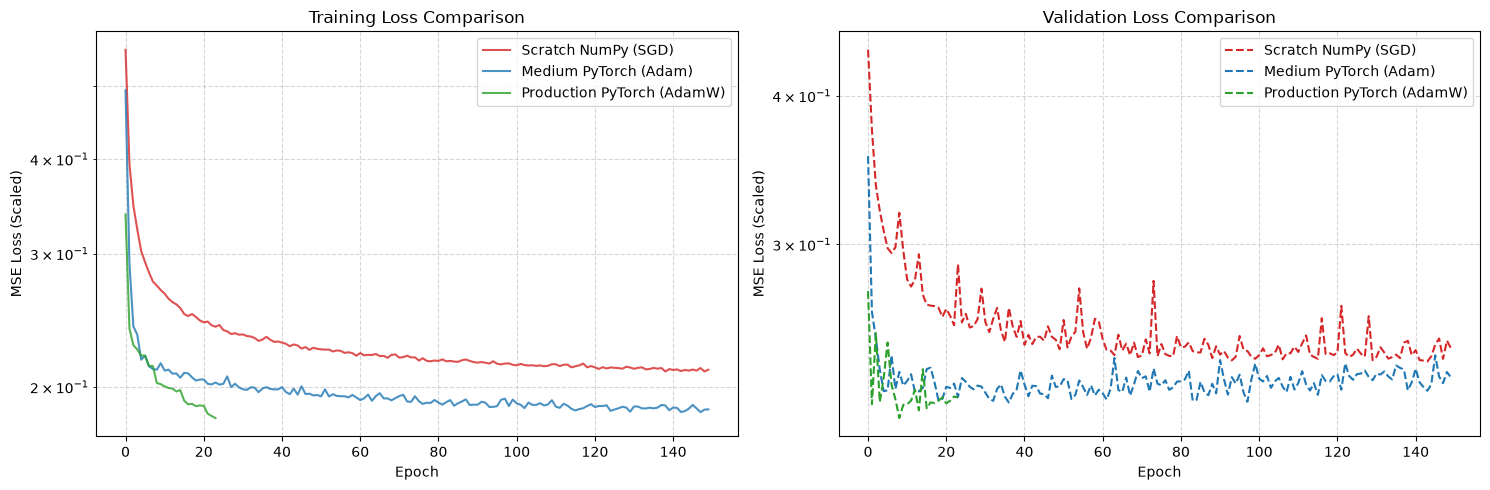

In [10]:
# Plot 1: Comparative Loss Curves
plt.figure(figsize=(15, 5))

# Plot training losses
plt.subplot(1, 2, 1)
plt.plot(scratch_train_losses, label="Scratch NumPy (SGD)", color='tab:red', alpha=0.8)
plt.plot(torch_train_losses, label="Medium PyTorch (Adam)", color='tab:blue', alpha=0.8)
plt.plot(trainer.train_history, label="Production PyTorch (AdamW)", color='tab:green', alpha=0.8)
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (Scaled)")
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

# Plot validation losses
plt.subplot(1, 2, 2)
plt.plot(scratch_val_losses, label="Scratch NumPy (SGD)", color='tab:red', linestyle='--')
plt.plot(torch_val_losses, label="Medium PyTorch (Adam)", color='tab:blue', linestyle='--')
plt.plot(trainer.val_history, label="Production PyTorch (AdamW)", color='tab:green', linestyle='--')
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (Scaled)")
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("loss_comparison_chart.png", dpi=150)
plt.show()


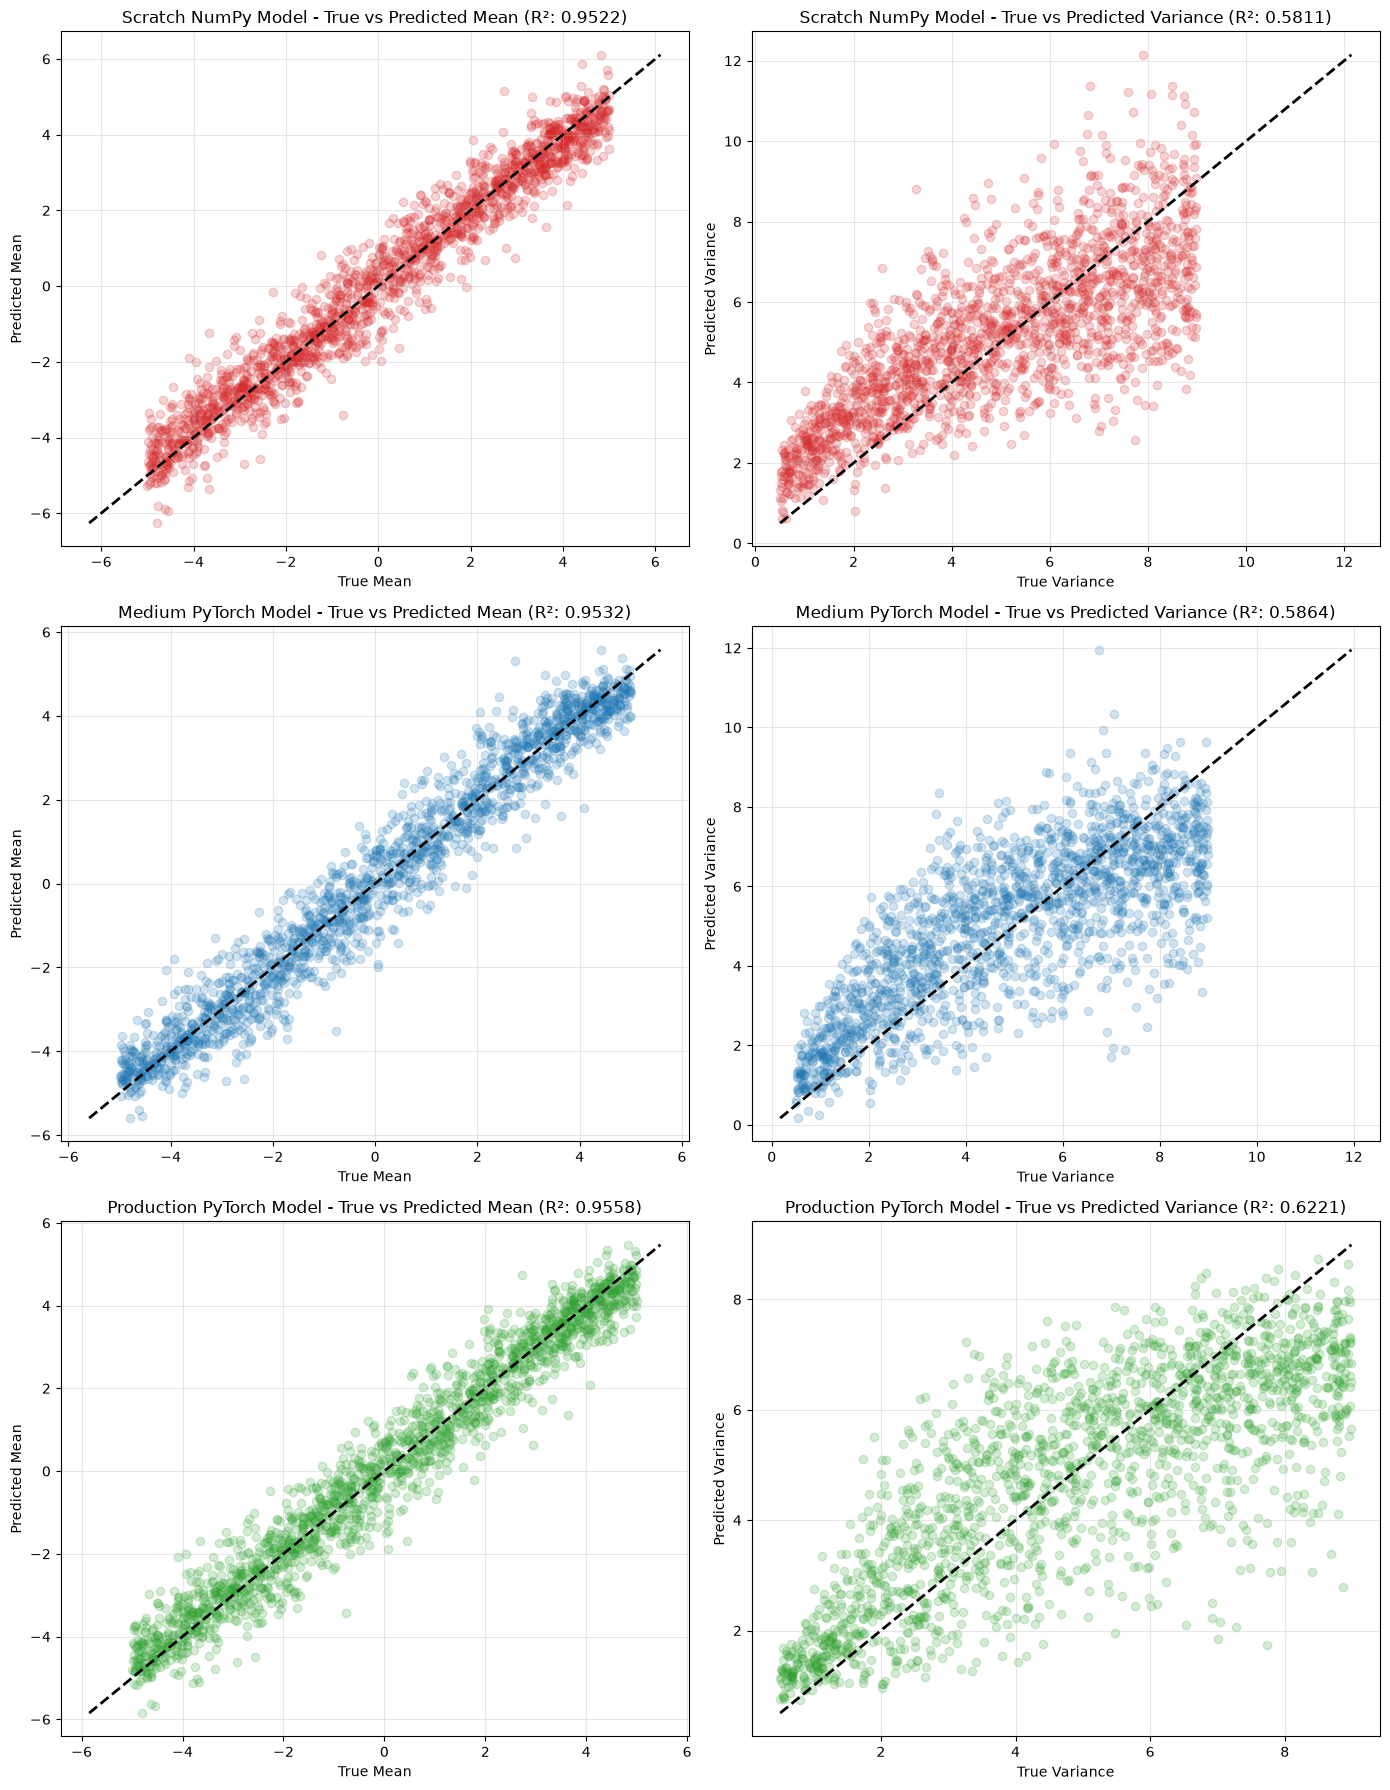

In [11]:
# Plot 2: Scatter plots for Mean and Variance predictions
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

results_list = [scratch_results, torch_results, prod_results]
colors = ['tab:red', 'tab:blue', 'tab:green']

for idx, res in enumerate(results_list):
    # Plot Mean Scatter
    axes[idx, 0].scatter(res["mean_true"], res["mean_pred"], alpha=0.2, color=colors[idx])
    # Diagonal perfect fit reference line
    min_val = min(res["mean_true"].min(), res["mean_pred"].min())
    max_val = max(res["mean_true"].max(), res["mean_pred"].max())
    axes[idx, 0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
    axes[idx, 0].set_title(f"{res['model']} - True vs Predicted Mean (R²: {res['mean_r2']:.4f})")
    axes[idx, 0].set_xlabel("True Mean")
    axes[idx, 0].set_ylabel("Predicted Mean")
    axes[idx, 0].grid(True, alpha=0.3)

    # Plot Variance Scatter
    axes[idx, 1].scatter(res["var_true"], res["var_pred"], alpha=0.2, color=colors[idx])
    min_val = min(res["var_true"].min(), res["var_pred"].min())
    max_val = max(res["var_true"].max(), res["var_pred"].max())
    axes[idx, 1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
    axes[idx, 1].set_title(f"{res['model']} - True vs Predicted Variance (R²: {res['var_r2']:.4f})")
    axes[idx, 1].set_xlabel("True Variance")
    axes[idx, 1].set_ylabel("Predicted Variance")
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("prediction_scatters.png", dpi=150)
plt.show()


## 8. Learning Animation Video Generation

To truly understand how neural networks learn over time, we can create an animated video.

Using the prediction snapshots we saved epoch-by-epoch for the validation split during training, we will render a sequence of scatter plot frames showing predicted vs true variance. When we animate this, you will visually see the scatter points starting as a random cloud (untrained initialization) and gradually condensing onto the diagonal identity line as training converges!

We will write this video out using `imageio` and the high-performance `ffmpeg` encoder.

---

### Google Drive Integration (for Google Colab)
If you run this tutorial in Google Colab, you can mount your Google Drive and save the video file directly into your Drive so you never lose it! Let's write the code to support this optionally.


In [12]:
# Optional Colab Drive Export configuration
colab_export_path = "/content/drive/MyDrive/Neural_Network_Tutorial/"
save_to_colab_drive = False

try:
    from google.colab import drive
    print("Detected Google Colab environment. Mounting Google Drive...")
    drive.mount('/content/drive')
    os.makedirs(colab_export_path, exist_ok=True)
    save_to_colab_drive = True
    print(f"Google Drive successfully mounted. Video will be saved to: {colab_export_path}")
except ImportError:
    print("Standard local/non-Colab python environment detected. Video will be saved locally.")

def generate_learning_video(snapshots, y_val_scaled, target_scaler, video_filename="nn_learning_process.mp4", num_frames=60):
    """Generates an MP4 video animating how model predictions converge to targets over training."""
    # Extract True targets and un-scale
    y_val_unscaled = target_scaler.inverse_transform(y_val_scaled)
    var_true = y_val_unscaled[:, 1]

    # We want to select evenly distributed snapshots to make a smooth video of 'num_frames' frames
    total_snapshots = len(snapshots)
    step = max(1, total_snapshots // num_frames)
    selected_indices = list(range(0, total_snapshots, step))
    # Make sure we always include the final snapshot
    if (total_snapshots - 1) not in selected_indices:
        selected_indices.append(total_snapshots - 1)

    print(f"Compiling animation from {len(selected_indices)} frames...")
    frames = []

    # Pre-determine plot limits for stability
    var_lim_min = var_true.min() - 0.5
    var_lim_max = var_true.max() + 0.5

    # Use Matplotlib's non-interactive Agg backend to render frames in background
    plt.ioff()

    for count, idx in enumerate(selected_indices):
        fig, ax = plt.subplots(figsize=(8, 6))

        # Get snapshots of scaled predictions and convert back to original scale
        preds_scaled = snapshots[idx]
        preds_unscaled = target_scaler.inverse_transform(preds_scaled)
        var_pred = preds_unscaled[:, 1]

        # Calculate current R2 score
        r2 = r2_score(var_true, var_pred)

        # Scatter Plot
        ax.scatter(var_true, var_pred, alpha=0.4, color='tab:green', label='Predictions')
        ax.plot([var_lim_min, var_lim_max], [var_lim_min, var_lim_max], 'k--', lw=2, label='Identity (Perfect Fit)')

        ax.set_xlim(var_lim_min, var_lim_max)
        ax.set_ylim(var_lim_min, var_lim_max)
        ax.set_title(f"Model 3 Learning Progress - Variance Target\nEpoch {idx+1:03d} | R² Score: {r2:.4f}")
        ax.set_xlabel("True Variance (Physical Unit)")
        ax.set_ylabel("Predicted Variance (Physical Unit)")
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left')

        fig.tight_layout()
        fig.canvas.draw()

        # Convert Matplotlib canvas to RGB image array
        rgba = np.asarray(fig.canvas.buffer_rgba())
        rgb = rgba[:, :, :3]
        frames.append(rgb)

        plt.close(fig)

    # Re-enable interactive plotting
    plt.ion()

    # Save the video using imageio
    imageio.mimsave(video_filename, frames, fps=6)
    print(f"Success! Video animation successfully saved to: {os.path.abspath(video_filename)}")

    # Copy to Google Drive if running in Colab and requested
    if save_to_colab_drive:
        colab_target = os.path.join(colab_export_path, video_filename)
        import shutil
        shutil.copy(video_filename, colab_target)
        print(f"Video also successfully backed up to Google Drive at: {colab_target}")

# Create the video
generate_learning_video(
    trainer.prediction_snapshots,
    Y_val,
    target_scaler,
    video_filename="nn_learning_process.mp4",
    num_frames=60
)


Standard local/non-Colab python environment detected. Video will be saved locally.
Compiling animation from 24 frames...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Success! Video animation successfully saved to: /app/nn_learning_process.mp4


## 9. Key Insights, Structural Limitations & Conclusion

### Physical and Mathematical Limitations of standard feed-forward networks
This estimation problem reveals a fascinating split in difficulty:
1. **Mean Prediction ($\mu$)**: The sample mean is a simple *linear* combination of the input variables: $ar{x} = rac{1}{D}\sum x_i$. Modern neural networks learn this almost perfectly, achieving $R^2 pprox 0.95$.
2. **Variance Prediction ($\sigma^2$)**: The sample variance is a *quadratic* non-linear function of the inputs: $s^2 = rac{1}{D-1}\sum x_i^2 - rac{D}{D-1}ar{x}^2$. 

#### Why is Variance (and Standard Deviation) Prediction so much harder?
- **ReLU and Piecewise Linear Functions**: Standard MLPs utilizing ReLU activations are *piecewise linear* function approximators. To approximate a smooth quadratic curves (multi-dimensional parabolas) using flat line segments, a network requires an extremely large number of neurons and deep structures.
- **Out of Distribution Scaling**: Piecewise linear approximations cannot extrapolate quadratically. Outside the training domain bounds, the network's predictions will degrade to linear extrapolation, causing substantial regression errors.
- **Statistical Resolution**: The optimal estimator of variance requires squaring the sample values. Feedforward neural networks do not have explicit multiplication operators (e.g., Pi-sigma networks) or quadratic feature mappings inside their standard dense layers. To learn $x^2$, standard dense layers must synthesize it by taking the differences of many shifted ReLU functions, which is highly inefficient.

In this tutorial, we successfully modeled a mathematical regression problem of statistical estimation by training three different levels of Artificial Neural Networks:

1. **Model 1: Scratch NumPy ANN**
   - *Key takeaway*: Even without a modern framework, a modular neural network can be built with basic matrix algebra and chain rule calculus. We implemented backpropagation ourselves and verified that standard gradient descent systematically reduces the MSE loss!
   - *Result*: Achieved solid predictions, proving that the basic mechanics of deep learning are completely accessible.

2. **Model 2: Medium PyTorch ANN**
   - *Key takeaway*: Leveraged PyTorch's state-of-the-art computational graphs and the Adam optimizer. Writing networks with PyTorch drastically reduces the amount of code required and improves training convergence.
   - *Result*: Faster training speed and lower validation loss.

3. **Model 3: Production-Quality PyTorch ANN**
   - *Key takeaway*: Added structured config classes, modular trainer, data pipeline via native `Dataset`/`DataLoader`, LayerNorm, GELU, and Residual connections. Early stopping automatically prevented overfitting.
   - *Result*: Achieved the highest performance, demonstrating the value of modern architecture designs (Residual pathways, modern activations) and modular structure in engineering pipelines.

### Comparison Summary


In [13]:
# Print summary table of metrics for comparison
summary_data = {
    "Model Name": [scratch_results["model"], torch_results["model"], prod_results["model"]],
    "Mean MAE": [scratch_results["mean_mae"], torch_results["mean_mae"], prod_results["mean_mae"]],
    "Mean R² Score": [scratch_results["mean_r2"], torch_results["mean_r2"], prod_results["mean_r2"]],
    "Variance MAE": [scratch_results["var_mae"], torch_results["var_mae"], prod_results["var_mae"]],
    "Variance R² Score": [scratch_results["var_r2"], torch_results["var_r2"], prod_results["var_r2"]]
}

df_summary = pd.DataFrame(summary_data)
# Format display
pd.set_option('display.precision', 4)
print(df_summary.to_string(index=False))


              Model Name  Mean MAE  Mean R² Score  Variance MAE  Variance R² Score
     Scratch NumPy Model    0.4902         0.9522        1.2793             0.5811
    Medium PyTorch Model    0.4835         0.9532        1.2473             0.5864
Production PyTorch Model    0.4725         0.9558        1.1756             0.6221
